# Air-only model: The Simplest Example

This notebook is a step-by-step user guide for the basic `elfe3D_GPR` workflow.
It demonstrates how to:

- define an air-only survey with the Python I/O layer,
- generate mesh and FEM input files,
- run TetGen and the Fortran solver, and
- compare computed fields to an analytical air-only reference.


In [13]:
import sys, os
%matplotlib inline
from pathlib import Path

# The `elfe3d_gpr` package provides the notebook-oriented Python I/O layer.
# It is installed from the repository root using `pip install -e .`.
# This package assembles model inputs, runs TetGen, and reads solver outputs.

# inputs
from elfe3d_gpr.inputs.survey import GPRSurvey

# runner
from elfe3d_gpr.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr.outputs.fieldreader import AnalyticalLoader, ElfeLoader, load_elfe_batch
from elfe3d_gpr.outputs.postprocess import field_error, all_errors, error_stats
from elfe3d_gpr.outputs.visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot)


## Paths and runtime configuration

This section defines the solver location and the execution mode.
`ProjectPaths` controls how the notebook launches the compiled `elfe3d_gpr` executable.


In [2]:
MASTER_PATH = Path(r"..\elfe3D_GPR").resolve()

paths = ProjectPaths(
    master_dir = MASTER_PATH,
    exec_rel   = r"elfe3d_gpr",
    use_wsl    = True,   # False if running the solver directly inside WSL
)

print('Solver root:', MASTER_PATH)
print('Executable:', paths.exec_path())


master   : F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR
exec     : F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


## 1: Build and write inputs

This step constructs the full model specification for the air-only case.
`GPRSurvey.build()` creates the domain, materials, source, receivers, solver settings, and PML configuration.
`survey.generate()` writes the `.poly` file for TetGen plus the FEM input files for the solver.


In [3]:
# Physical setup: air-only domain with a thin placeholder layer.
# The current I/O implementation requires at least one earth layer,
# so the layer is set to match air properties exactly.
f    = 100e6
wave = 3e8 / f     # free-space wavelength = 3.0 m
survey = GPRSurvey.build(
    experiment_name = 'air_only',
    base_dir        = MASTER_PATH,

    # Domain
    x_e = [-wave/10, 1 + wave/10],
    y_e = [-wave/10,     wave/10],
    z_e = [-wave/10,     wave/10],

    # Materials — air only (whole-space)
    air_eps_r = 1.0,
    air_sigma = 1e-16,
    layer_thicknesses = [wave/10],  # thin dummy layer required by current implementation
    layer_eps_r       = [1.0],      # same as air
    layer_sigma       = [1e-16],
    layer_mu_r        = [1.0],
    layer_sigma_m     = [0.0],

    # Source
    ricker_central_f    = f,
    num_points_per_range = 1,
    antenna_position    = [0.0, 0.0, 0.025],
    source_type         = 6,
    current_direction   = 1,
    num_segments        = 1,
    s_f                 = 250,
    bh_f                = 1.0,
    box_present         = False,
    box_x               = [-1.0, 1.0],

    # Receivers  (inline = endfire/CO survey along x)
    num_receivers_inline  = 48,
    num_receivers_endfire = 0,
    num_receivers_oblique = 0,

    # Solver
    solver_type      = 2,
    max_ref_steps    = 0,
    max_unknowns     = 5_000_000,
    accuracy_tol     = 3e-5,
    output_fields_vtk = 1,

    # PML
    num_pml_layers      = 1,
    pml_layer_thickness = wave/10,
    pml_type            = 'lin',
    pml_decay_type      = 1,

    least_samples_per_wavelength = 40,
)

survey.generate()
print('poly :', survey.io.poly_file)
print('inputs:', survey.io.input_dir)


odepths: [np.float64(0.01875), np.float64(0.01875)]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
[0.0]
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_air_only.poly
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\elfe3D_input.txt
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\source.txt
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\regionparameters.txt
Input generation complete.
poly : F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_air_only.poly
inputs: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in


## 2: Mesh generation with TetGen

TetGen converts the generated `.poly` geometry into a tetrahedral mesh.
This mesh is required by the FEM solver to discretize the air-only domain.


In [4]:
# TetGen reads the generated .poly geometry and builds the mesh.
# The mesh is stored alongside the input files in the survey input directory.
run_tetgen(paths, survey.io.poly_file)


── TetGen ────────────────────────────────────────────
   cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/in && /usr/bin/tetgen -pq1.2kAaen GPR_model_air_only.poly

Opening GPR_model_air_only.poly.
Delaunizing vertices...
Delaunay seconds:  0.003602
Creating surface mesh ...
Surface mesh seconds:  0.002946
Constrained Delaunay...
Constrained Delaunay seconds:  0.004062
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000226
Refining mesh...
Refinement seconds:  2.11802
Optimizing mesh...
Optimization seconds:  0.08098

Writing GPR_model_air_only.1.node.
Writing GPR_model_air_only.1.ele.
Writing GPR_model_air_only.1.face.
Writing GPR_model_air_only.1.edge.
Writing GPR_model_air_only.1.vtk.
Writing GPR_model_air_only.1.neigh.

Output seconds:  1.27851
Total running seconds:  3.48901

Statistics:

  Input points: 226
  Input facets: 118
  Input segments: 329
  Input holes: 0
  Input regions: 36

  Mesh points: 75506
  Mesh tetrahedra:

## 3: Run the Fortran solver

This step launches the compiled solver executable using the configured `ProjectPaths`.
The solver reads the FEM input files from the survey folder and writes field results to the output directory.


In [5]:
# Run the Fortran solver. The solver reads the prepared input files
# and writes electric field output to the survey output directory.
run_solver(paths, survey)


── elfe3d_gpr ────────────────────────────────────────
   wsl bash -c cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR && /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/elfe3d_gpr

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions
Your input meshfile is called
 in/GPR_model_air_only.                            
Your mesh has
       75506 Nodes
      448111 Elements
      531697 Edges (dof)
*************************************
Assembling connectivity arrays
Calcul

## 4: Load solver results

The solver output is stored in the survey output directory.
`ElfeLoader` reads the electric field receiver-line file and converts it to the endfire result format used for plotting and comparison.


In [6]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
print('reading:', result_txt)

# Load the receiver-line electric field result from the solver output.
# Here we use the same number of endfire receivers as defined above.
ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D  air_only',
    num_endfire = 48,   # matches num_receivers_inline above
).endfire()

print(f'r : {ef.r.min():.3f} - {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_air_only\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## 5: Analytical reference for the air-only case

This reference dataset is a semi-analytical solution for a homogeneous air domain at 100 MHz.
The comparison helps validate the solver output against a known analytical result.


In [ ]:
# Half-space analytical quadrature reference (eps_r = 1 everywhere)
ANALYTICAL_DIR = r'F:\Projects\EMGeoInversion\elfe3D_GPR\data\data_semi_analytical'

analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_air_100MHz_NR.csv'),
    label='analytical',
).endfire()


## 6: Compare computed field to analytical reference

This plot shows the computed endfire electric field together with the analytical reference.
A close match indicates the solver correctly reproduces the air-only response.


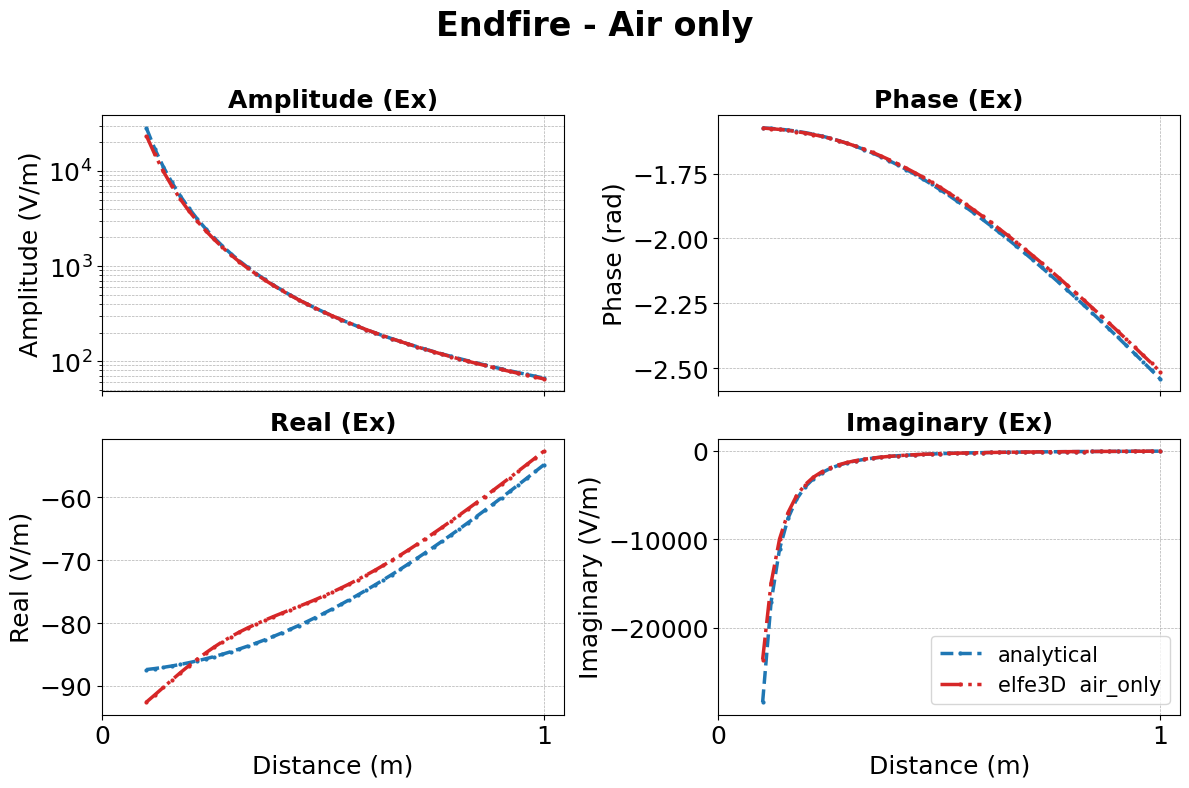

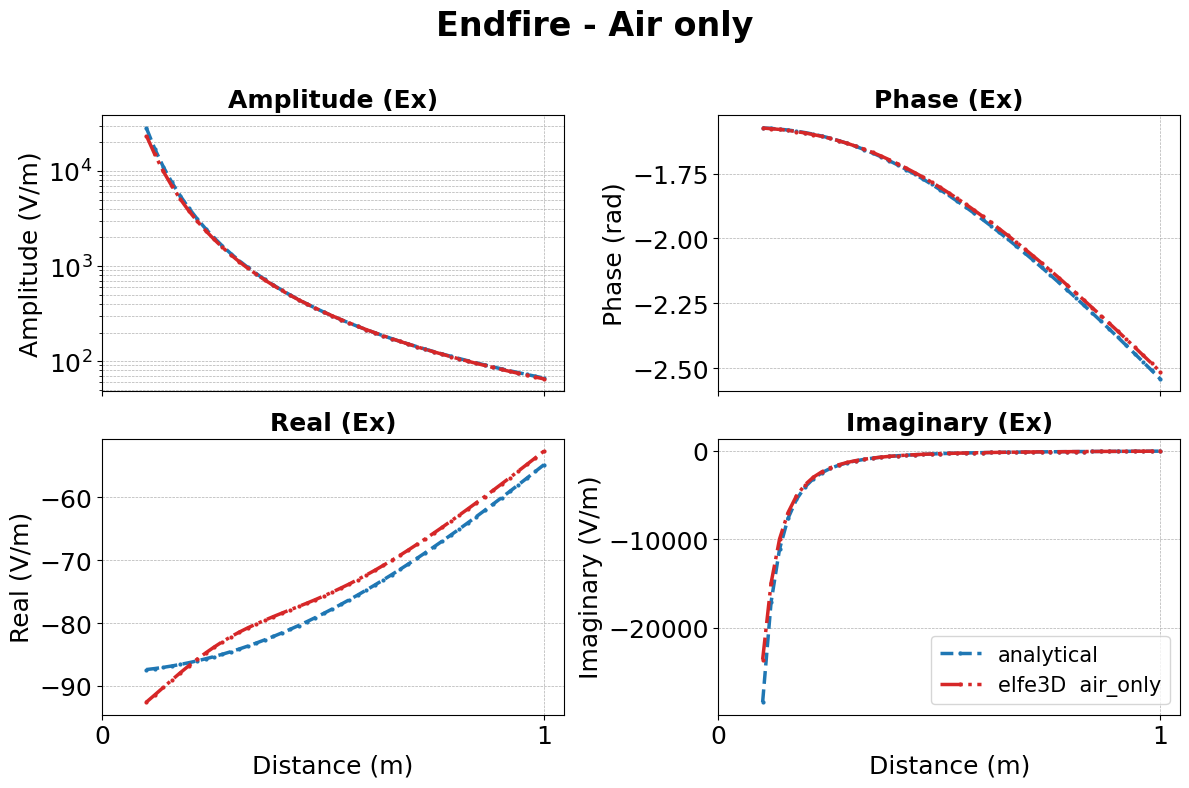

In [8]:
ReceiverLinePlot([analytical, ef],).plot(suptitle='Endfire - Air only')


## Error plot and quality check

This plot highlights the difference between the computed result and the analytical reference.
Small error magnitudes indicate good solver agreement in the air-only case.


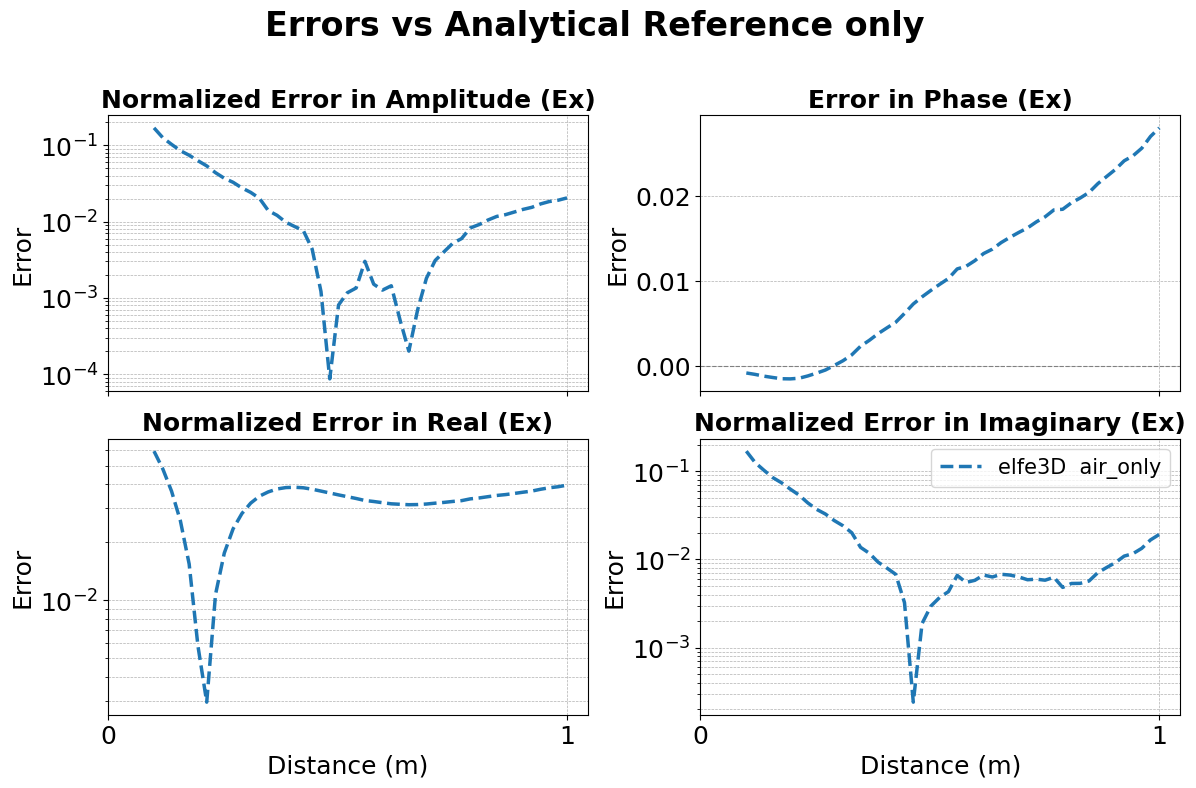

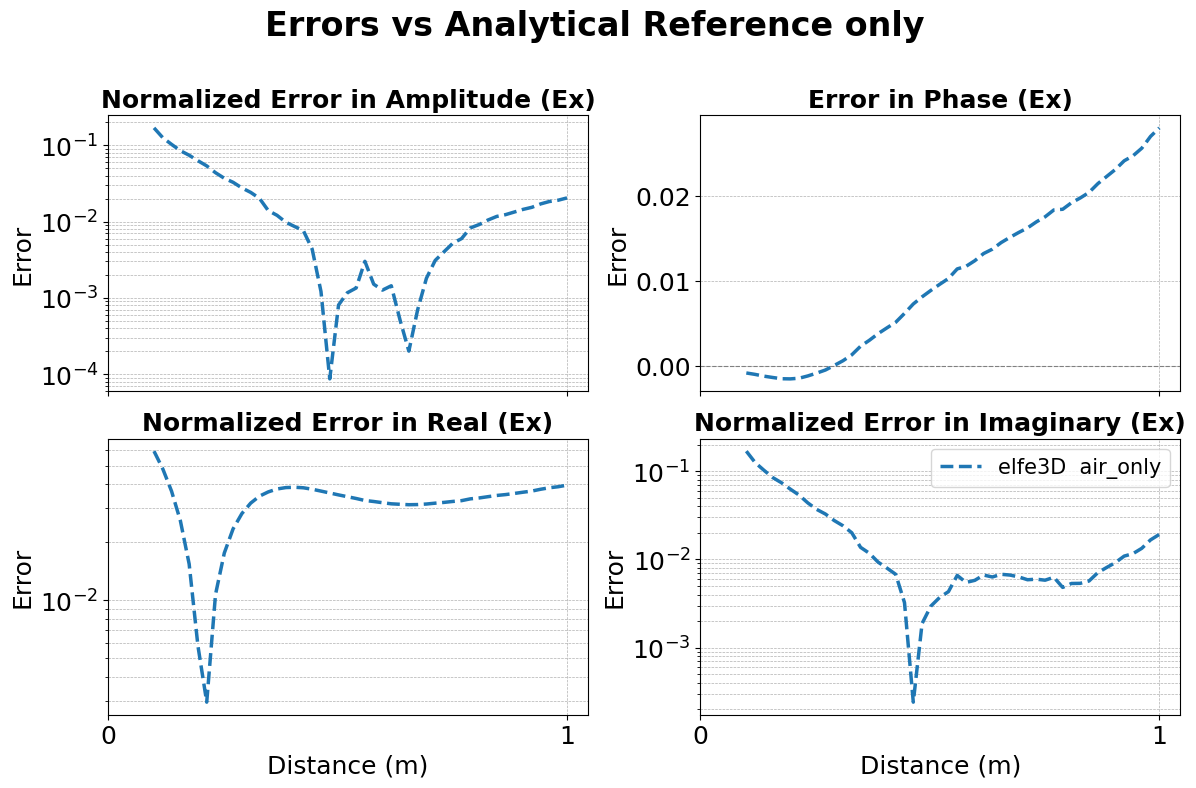

In [9]:
ReceiverLineErrorPlot([ef], reference=analytical).plot(suptitle='Errors vs Analytical Reference only')

## Combined field and error plot

Here we overlay the field and error visualizations to inspect the results in one view.
This helps confirm whether the error structure is consistent across receivers.


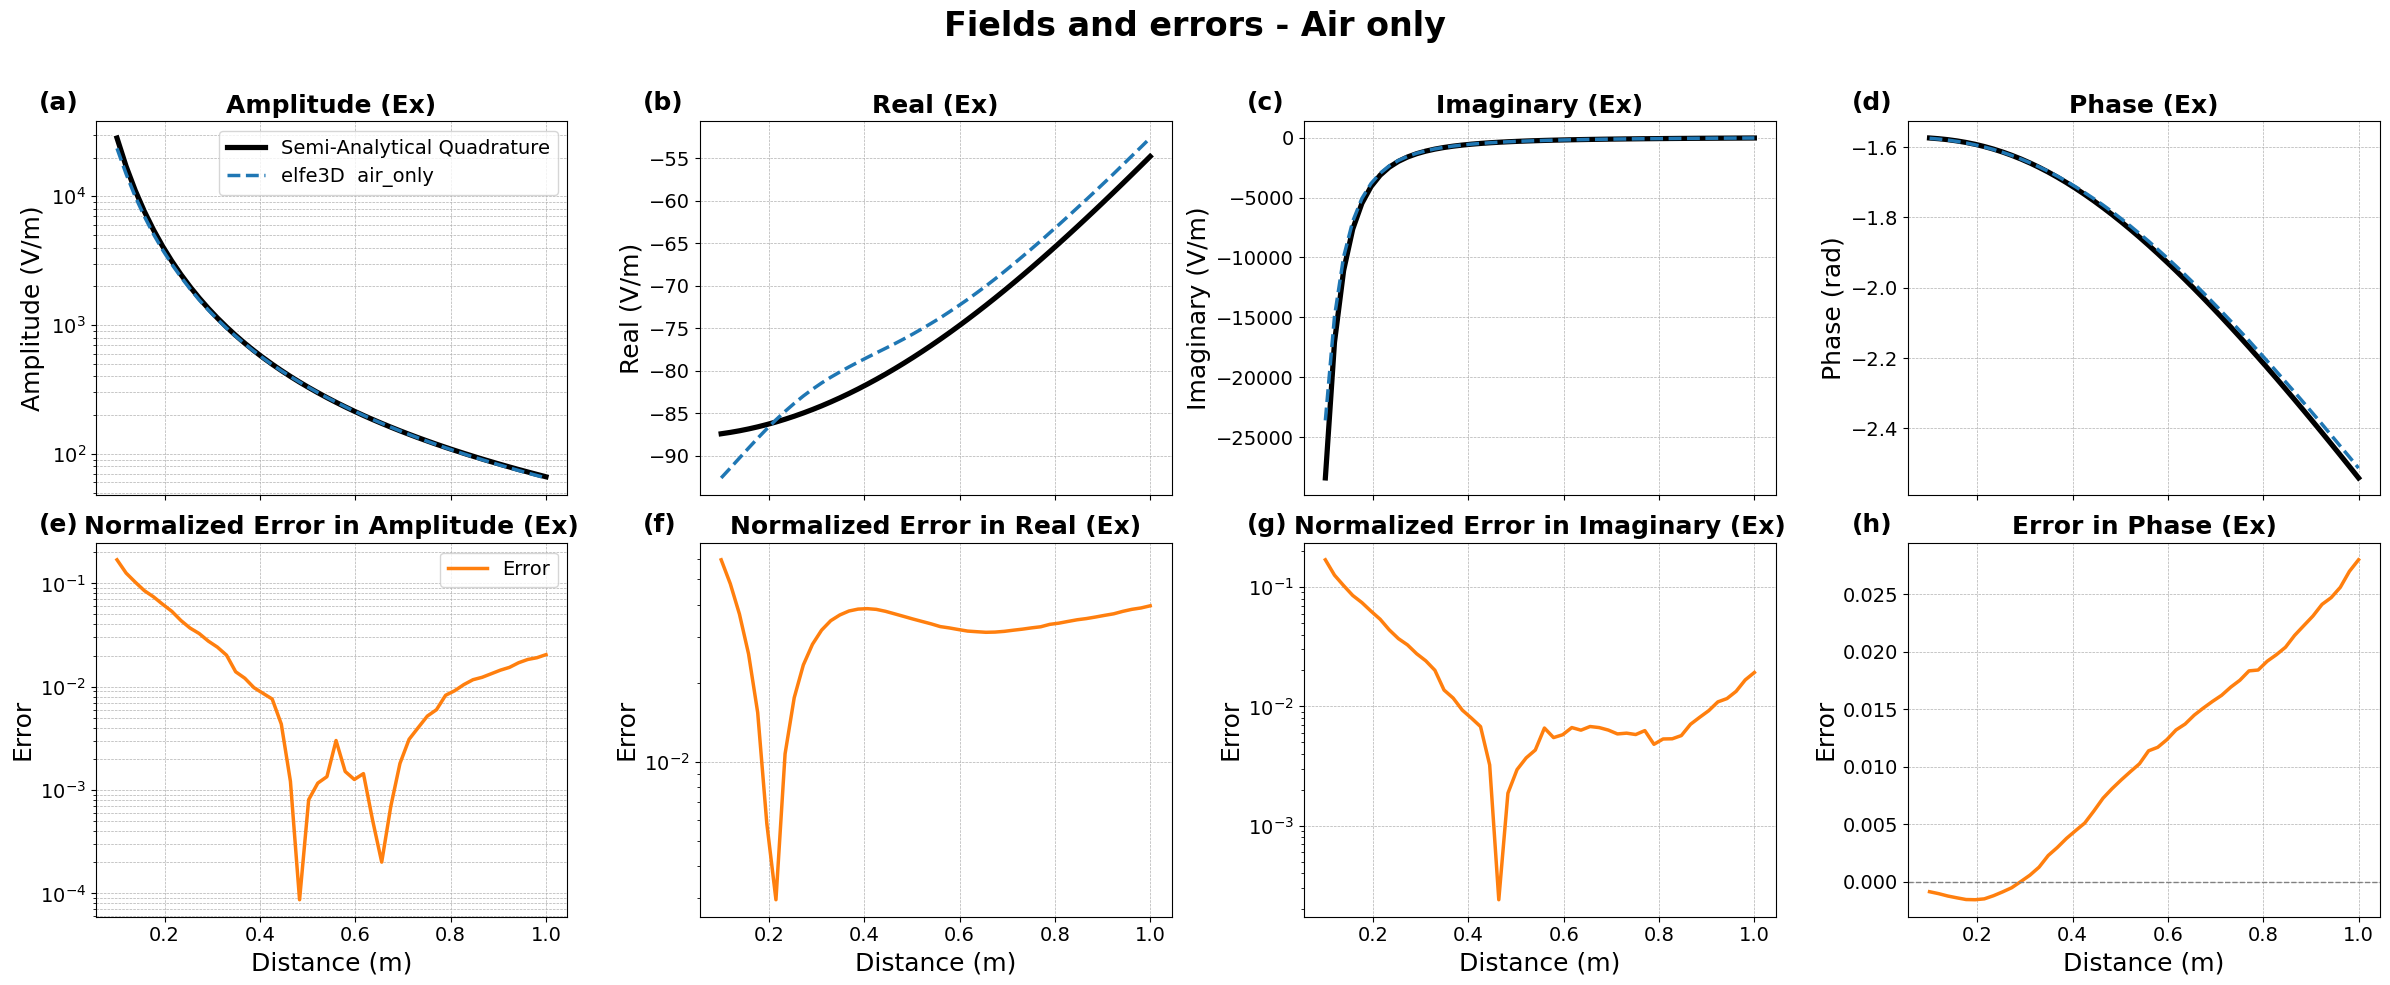

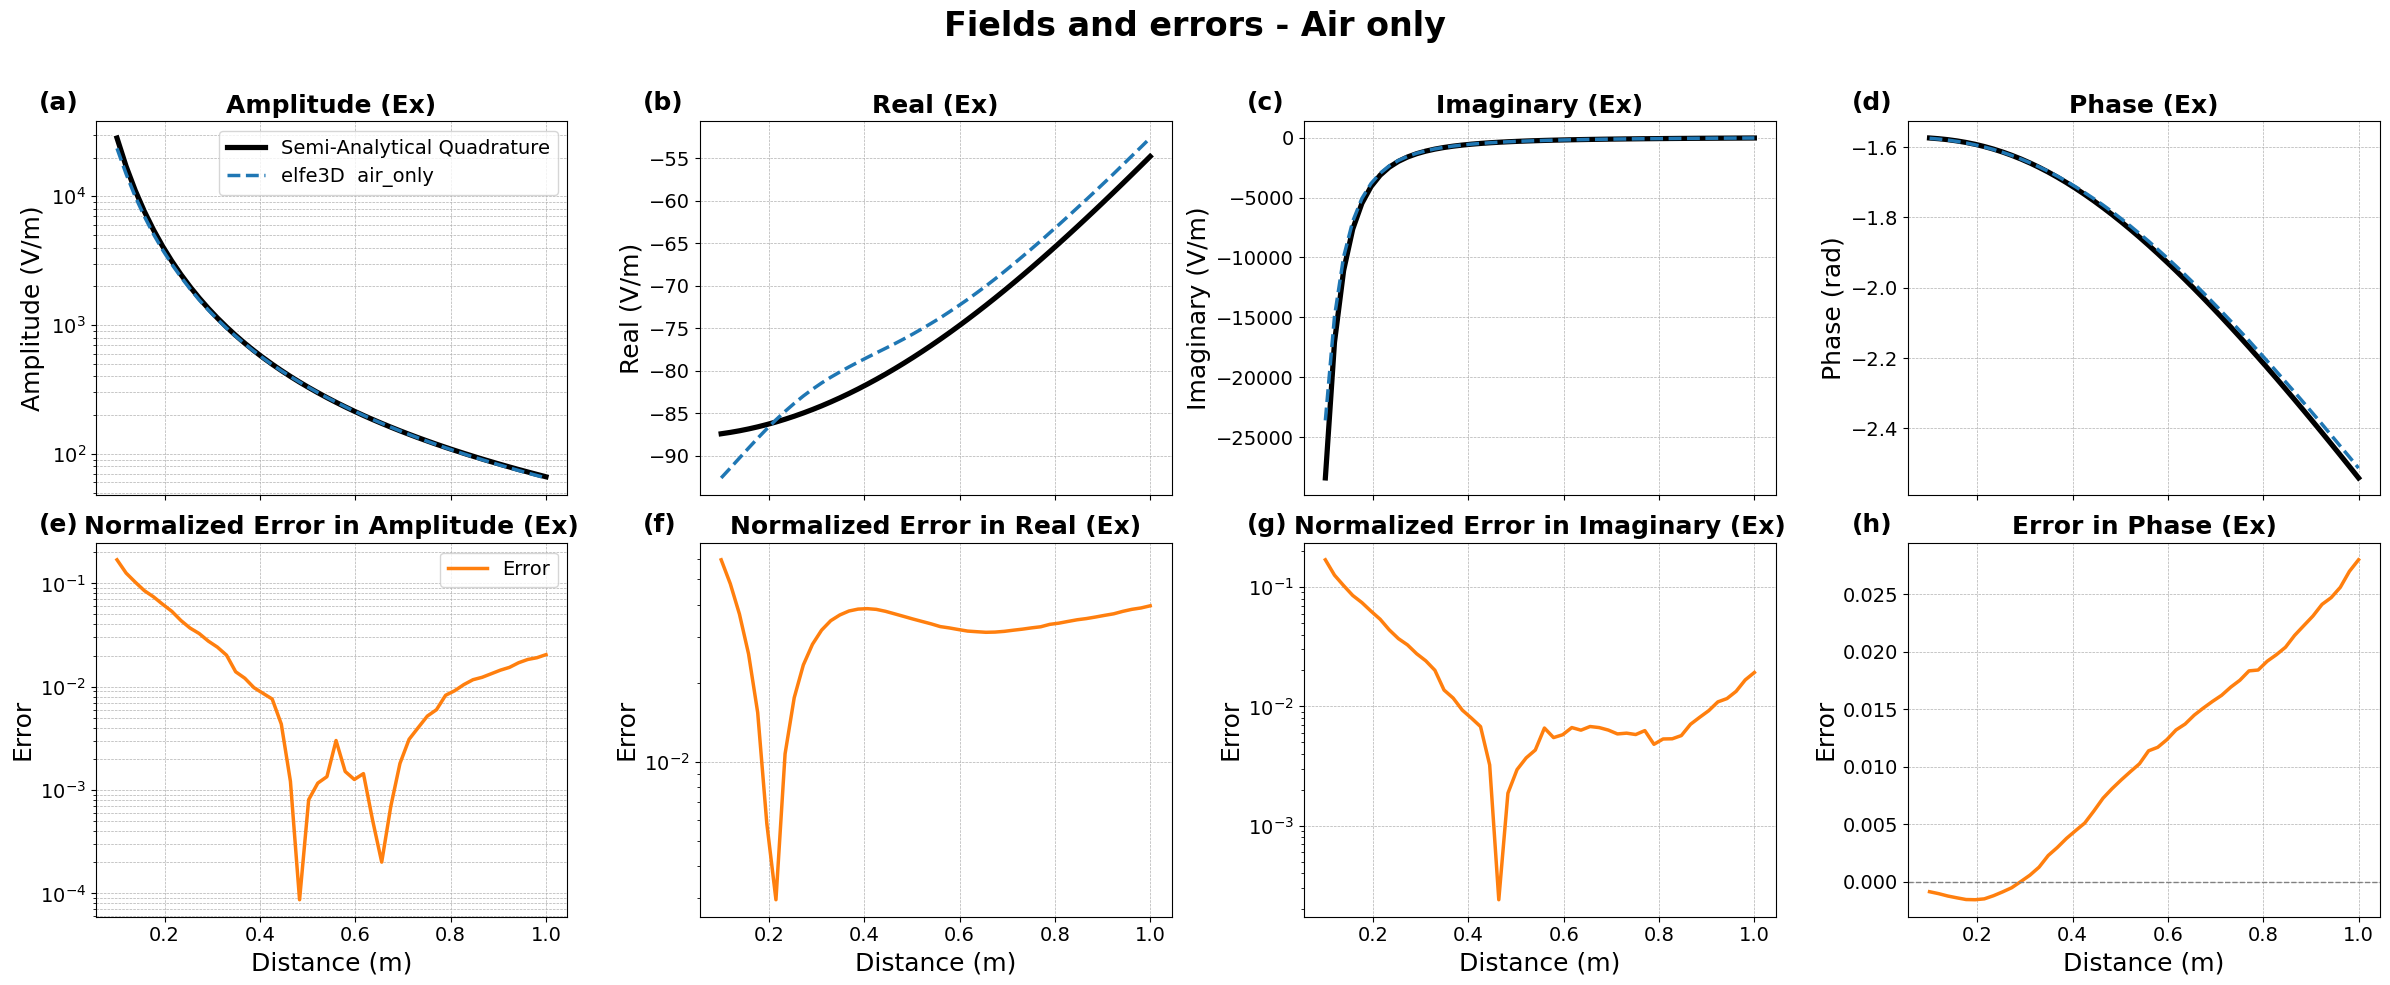

In [10]:
ReceiverLineCombined(ef, analytical).plot(suptitle='Fields and errors - Air only')


## Error distribution histogram

The histogram shows the distribution of errors relative to the analytical reference.
It is useful for identifying systematic bias or large outliers in the computed field.


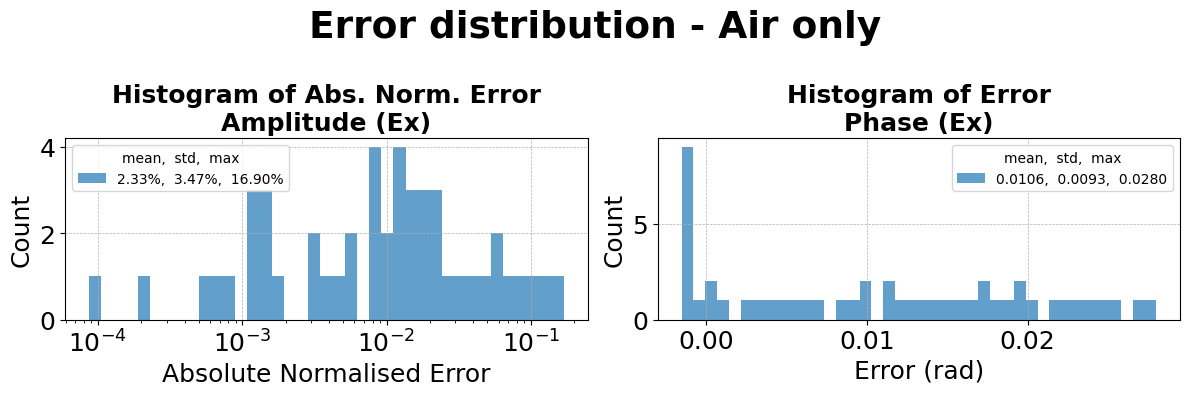

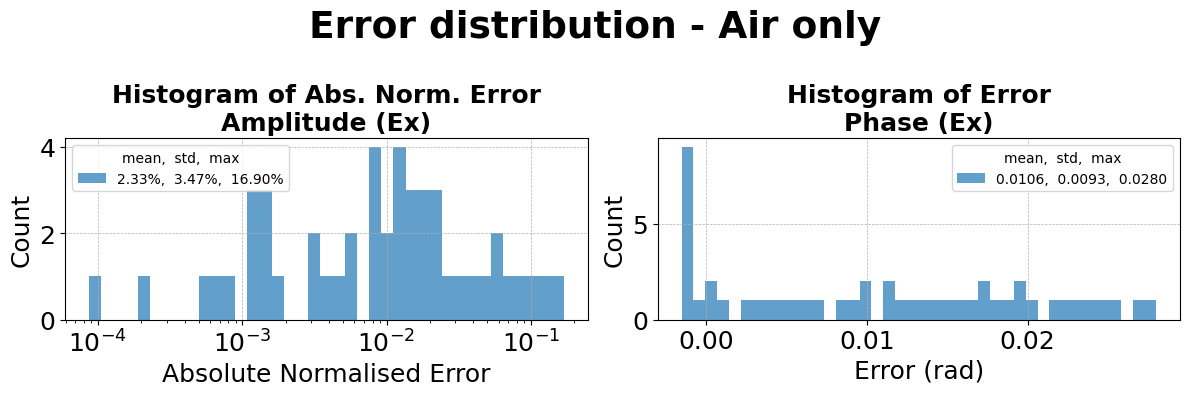

In [11]:
ErrorHistogramPlot([ef], reference=analytical).plot(suptitle='Error distribution - Air only')

## Numerical error summary

This summary computes mean, standard deviation, and maximum error for amplitude, phase, real, and imaginary components.
These statistics quantify agreement with the analytical solution.


In [12]:
qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
print(f'\n── {ef.label} ──')
for qi, name in enumerate(qty_names):
    err = field_error(analytical, ef, qi)
    m, s, mx = error_stats(err)
    scale, unit = (100, '%') if qi != 1 else (1, 'rad')
    print(f'  {name:12s}:  mean={m*scale:.3f}{unit}  '
          f'std={s*scale:.3f}{unit}  max={mx*scale:.3f}{unit}')



── elfe3D  air_only ──
  Amplitude   :  mean=2.329%  std=3.470%  max=16.905%
  Phase       :  mean=0.011rad  std=0.009rad  max=0.028rad
  Real        :  mean=3.263%  std=0.930%  max=5.940%
  Imaginary   :  mean=2.326%  std=3.448%  max=16.905%


## Conclusions

This notebook demonstrates the core `elfe3D_GPR` workflow for an air-only model.
The solver output is compared to a semi-analytical reference, and the error metrics show how well the computed field matches the expected air response.

Next steps:
- explore the homogeneous-earth example to add material contrast,
- run the two-layered-earth case to validate subsurface layering,
- inspect how receiver geometry affects the field results.
